In [20]:
import math
import numpy as np

In [60]:
# Implementation of the class to represent a value in the computation graph
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        res = Value(self.data + other.data, _children=(self, other), _op='+')

        def _backward():
            self.grad += 1.0 * res.grad
            other.grad += 1.0 * res.grad
        
        res._backward = _backward
        return res

    def __mul__(self, other):
        res = Value(self.data * other.data, _children=(self, other), _op='*')

        def _backward():
            self.grad += other.data * res.grad
            other.grad += self.data * res.grad
        
        res._backward = _backward
        return res

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        res = Value(t, (self, ), 'tanh')
    
        def _backward():
            self.grad += (1 - t**2) * res.grad
        
        res._backward = _backward
    
        return res
  
    
    def backward(self):
    
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [37]:
# Function to visualize the computation graph using Graphviz

from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [62]:
# Forward Pass Example
x1 = Value(2.0, label='x1')
x2 = Value(3.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')
# Compute the output of the network
x1w1 = x1 * w1; 
x1w1.label = 'x1*w1'
x2w2 = x2 * w2; 
x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2;
x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b;
n.label = 'n'
o = n.tanh();
o.label = 'o'

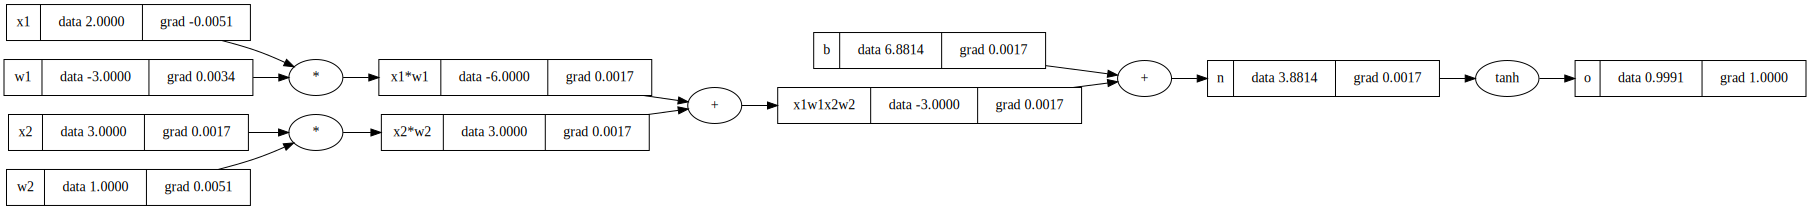

In [65]:
draw_dot(o)

In [64]:
# Perform backward pass to compute gradients
o.backward()